# 10.5 Random Forest and Model Complexity

# 1. Limitations of Naïve Bayes

In the previous sections we trained a Naïve Bayes classifier to predict compound activity from MACCS fingerprints. Naïve Bayes is a useful starting model because it is fast, interpretable, and easy to train. For many problems it can produce surprisingly strong results. However, Naïve Bayes relies on a very strong assumption: it treats each feature as independent of the others given the class label.

For molecular fingerprints, this assumption is rarely true. MACCS keys represent structural fragments of molecules. In real chemical structures, fragments are often related. The presence of one feature can increase or decrease the probability of another feature appearing in the same molecule. For example, two functional groups may commonly occur together within a particular scaffold, or the presence of one substructure may exclude another due to chemical constraints.

Because Naïve Bayes assumes independence between features, it cannot naturally capture these interactions between structural fragments. Instead, it treats each feature as if it contributes to activity independently. In practice this means the model may miss patterns that depend on combinations of features, such as:

* two substructures that together increase activity
* a fragment that only matters when another fragment is present
* mutually exclusive structural motifs

To capture these types of relationships we need models that can learn interactions between features directly from the data.

One family of models that can do this effectively is tree-based models. Decision trees split data according to feature values, allowing them to represent complex relationships between variables. When many trees are combined together, the result is a powerful ensemble model known as a Random Forest.

In the next section we will first examine **decision trees**, the basic building blocks of Random Forest models.

# 2. Decision Trees

Decision trees are a class of machine learning models that make predictions by applying a sequence of feature-based decisions. Instead of calculating probabilities for each feature independently (as in Naïve Bayes), a decision tree repeatedly splits the data into smaller groups based on feature values. Each split asks a simple question about the data.

For example, if we are using MACCS fingerprints, a decision rule might look like this:

```
If MACCS key 42 is present → go left
If MACCS key 42 is absent → go right
```

Each branch of the tree continues to split the data using additional features until the model reaches a terminal node, often called a leaf. At that point the model assigns a class prediction, typically based on the majority class of the training samples in that leaf.

Conceptually, a decision tree builds a structure like this:

```
            MACCS_42 ?
           /        \
        yes          no
     MACCS_87 ?    inactive
     /       \
 active    inactive
```

Each path through the tree corresponds to a set of logical rules derived from the training data.

## 2.1 Learning Feature Interactions

One important advantage of decision trees is that they naturally learn interactions between features.

For example, the tree might learn a rule like:

```
If MACCS_42 == 1 AND MACCS_87 == 1 → active
```

This type of relationship is difficult for Naïve Bayes to capture because Naïve Bayes evaluates each feature independently. Decision trees, however, can represent complex relationships between features by stacking multiple decision rules along a path in the tree.

## 2.2 Decision Tree Classifier in scikit-learn

In scikit-learn, decision trees are implemented through the `DecisionTreeClassifier` estimator.

```python
from sklearn.tree import DecisionTreeClassifier
```

Like the other models we have used, this estimator follows the standard scikit-learn interface:

```
.fit()
.predict()
.predict_proba()
```

Because it follows the same interface, it can be used directly inside a pipeline.

## 2.3 Example: Decision Tree Pipeline

Below is a minimal example using the same feature processing pipeline we used for Naïve Bayes.

```python
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ("var", variance_filter),
    ("tree", DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)
```

<a id="load-feature-matrix"></a>

### 2.3.1 Load Data and Create Feature Matrix


In [1]:
# Load MACCS fingerprint dataset

from pathlib import Path
import pandas as pd

data_path = Path(
    "data/AID743139/features/"
    "AID743139_MACCS_activities_noSalt_20260205.csv"
)

df = pd.read_csv(data_path)

# Separate features and labels
label_column = "activity"
maccs_columns = [c for c in df.columns if c.startswith("maccs")]

X = df[maccs_columns]
y = df[label_column]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (6793, 167)
Label vector shape: (6793,)


### 2.3.2 Train/Test Split and Train the Model

In [2]:
# Train/test split and Decision Tree pipeline

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=3100,
    stratify=y
)

tree_pipeline = Pipeline([
    ("var_filter", VarianceThreshold(threshold=0.0)),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained.")

Decision Tree model trained.


### 2.3.3 Predictions and Confusion Matrix

In [3]:
# Evaluate the Decision Tree model

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score
)

# Predictions
y_pred = tree_pipeline.predict(X_test)

# Predicted probabilities for the positive class (activity = 1)
y_prob = tree_pipeline.predict_proba(X_test)[:, 1]

# Metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
train_acc = tree_pipeline.score(X_train, y_train)

print("Confusion Matrix:")
print(cm)

print(f"\nAccuracy:           {acc:.3f}")
print(f"Balanced Accuracy:  {bal_acc:.3f}")
print(f"AUC:                {auc:.3f}")
print(f"Training Accuracy:   {train_acc:.3f}")
print(f"Test Accuracy:       {acc:.3f}")

Confusion Matrix:
[[574  32]
 [ 47  27]]

Accuracy:           0.884
Balanced Accuracy:  0.656
AUC:                0.688
Training Accuracy:   0.992
Test Accuracy:       0.884



## 2.4 The Problem with Single Trees

Although decision trees are flexible and easy to interpret, they can easily overfit the training data. In many cases a tree can achieve extremely high training accuracy while performing substantially worse on unseen test data. This occurs because the tree learns a very specific set of rules that match the training molecules closely but do not generalize well to new compounds.

In the example above, the decision tree achieves very high accuracy on the training data (0.992), but performs noticeably worse on the unseen test set (0.884). This difference suggests that the model has begun to overfit the training data, learning patterns that do not generalize perfectly to new molecules.

# 3. Why Single Trees Are Unstable

In the previous section we observed that the decision tree achieved very high accuracy on the training data but somewhat lower accuracy on the unseen test set. This behavior suggests that the model has begun to overfit the training data. Another important limitation of decision trees is that they can be highly sensitive to the training data itself. When a decision tree is trained, it repeatedly selects the feature that produces the best split at each step. These decisions are made using only the samples available at that moment in the training data. Because of this, even small differences in the dataset can lead the algorithm to choose different early splits.

Once the first few splits change, the entire structure of the tree may change as well. As a result, two trees trained on slightly different samples of the same dataset can produce noticeably different models. This behavior is known as model instability or high variance. 

In [4]:
from sklearn.tree import DecisionTreeClassifier

tree1 = DecisionTreeClassifier(random_state=1)
tree2 = DecisionTreeClassifier(random_state=2)

tree1.fit(X_train, y_train)
tree2.fit(X_train, y_train)

pred1 = tree1.predict(X_test)
pred2 = tree2.predict(X_test)

print("Predictions identical?", (pred1 == pred2).all())

Predictions identical? False


In practice this means that the predictions of a single decision tree may depend strongly on the specific training sample used to construct the model. If the training dataset changes slightly, the resulting tree may produce different decision rules and different predictions. Machine learning practitioners often address this problem by combining many decision trees rather than relying on a single one. By averaging the predictions of many trees trained on slightly different data samples, the overall model becomes much more stable. This idea forms the basis of the Random Forest algorithm, which we will explore in the next section.

# 4 Random Forest — The Core Idea

Decision trees are powerful models because they can learn complex relationships between features. However, as we saw in the previous section, a single tree can be unstable and prone to overfitting. One way to address this problem is to train many decision trees instead of just one, and then combine their predictions. This idea is known as an ensemble method. Random Forest is an ensemble learning algorithm that builds a large collection of decision trees and combines their predictions to produce a more stable and accurate model.

Instead of relying on a single tree, Random Forest trains many trees that each see slightly different versions of the data. The final prediction is then determined by aggregating the predictions of all trees, typically through majority voting in classification problems. By averaging many trees, Random Forest reduces the instability that occurs when relying on a single decision tree.

## 4.1 Bootstrap Sampling

The first source of randomness in Random Forest is bootstrap sampling. Bootstrap sampling means that each tree in the forest is trained on a random sample of the training data drawn with replacement. That is, after a data point has been selected, it is placed back into the pool and can be selected again.

For example, suppose we have the following small dataset:

```
Molecule IDs
1 2 3 4 5
```

A bootstrap sample might look like:

```
3 5 2 2 4
```

Notice that:

* some molecules appear multiple times
* some molecules may not appear at all

Each decision tree in the forest is trained on a different bootstrap sample of the data. This means every tree sees a slightly different version of the training set, which leads to different learned decision rules.

## 4.2 Random Feature Selection

The second source of randomness occurs during the construction of each tree. When a decision tree chooses a split, it normally considers all available features to find the best split. In a Random Forest, however, the algorithm only considers a random subset of features at each split.

For example, if the fingerprint contains 166 MACCS features, the algorithm might consider only a subset of them when evaluating possible splits. This prevents the same strong features from dominating every tree and helps ensure that the trees in the forest are less correlated with each other.

## 4.3 Aggregating Predictions and Voting

Once many trees have been trained, the Random Forest combines their predictions. A collection of models that work together in this way is called an ensemble. For classification problems, the forest typically uses majority voting. Each tree predicts a class label, and the final prediction is the class that receives the most votes across all trees.
```
Tree predictions:

Tree 1 → Active  
Tree 2 → Inactive  
Tree 3 → Active  
Tree 4 → Active  
Tree 5 → Inactive  

Final prediction → Active
```
Because the final prediction reflects the consensus of many trees, the overall model becomes more stable and less sensitive to noise in the training data. Ensemble methods often improve predictive performance by combining the strengths of multiple models while reducing the weaknesses of any individual model.

# Random Forest Hyperparameters
Random Forest models contain many adjustable settings that control how the forest is constructed. These settings are called hyperparameters. Understanding hyperparameters is important because they influence how the model learns from data and how complex the resulting model becomes. Before examining the specific hyperparameters used by Random Forest, it is helpful to distinguish between parameters learned by a model and hyperparameters chosen by the user.

## 5.1 Parameters vs Hyperparameters

In machine learning, a parameter is a value that the model learns automatically from the training data. For example, in a decision tree the algorithm learns:

* which features to split on
* the thresholds used for each split
* the overall structure of the tree

These values are not chosen by the user. They are determined during model training when we call:

```
.fit()
```

Hyperparameters are different. A hyperparameter is a setting that controls how the learning algorithm constructs the model. Examples include:

* the number of trees in a Random Forest
* the maximum depth of each tree
* the number of features considered when making splits

These values must be chosen before training begins.

## 5.2 Hyperparameters in scikit-learn Estimators

In **scikit-learn**, machine learning models are implemented as **estimators**. An estimator is a Python object that implements methods such as:

```
.fit()
.predict()
.predict_proba()
```

The `RandomForestClassifier` is an example of an estimator. When we create one, we can specify hyperparameters as arguments.

```python
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
```
## 5.3 Key Random Forest Hyperparameters

The Random Forest algorithm contains many hyperparameters, but only a few have a strong influence on model behavior. The most important ones control the size of the forest and the complexity of the individual trees.

| Hyperparameter     | Purpose                                           |
| ------------------ | ------------------------------------------------- |
| `n_estimators`     | Number of decision trees in the forest            |
| `max_depth`        | Maximum depth of each tree                        |
| `max_features`     | Number of features considered at each split       |
| `min_samples_leaf` | Minimum number of samples required in a leaf node |

These hyperparameters affect the balance between model flexibility and generalization.

For example:

* Increasing `n_estimators` generally makes predictions more stable.
* Limiting `max_depth` can reduce overfitting.
* Adjusting `max_features` increases randomness between trees, which helps reduce correlation among them.

Choosing appropriate values for these hyperparameters can improve model performance.

## 5.4 Inspecting Available Hyperparameters

Scikit-learn provides a convenient way to inspect the hyperparameters available for an estimator. For example, we can create a Random Forest model and view its configuration:

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

# 6 Integrating Random Forest into the Pipeline

In previous sections we used a pipeline workflow to train and evaluate a Naïve Bayes model using MACCS fingerprints. One advantage of pipelines is that they allow us to replace the classifier while keeping the rest of the workflow unchanged. In this section we will construct a new pipeline that uses a Random Forest classifier instead of Naïve Bayes. The preprocessing step and the feature matrix remain exactly the same.

## 6.1 Constructing the Random Forest Pipeline

As before, the pipeline will contain two steps:

1. A variance filter that removes features with no variability
2. A classifier that performs the prediction

The classifier in this case will be `RandomForestClassifier`.

<div class="alert alert-block alert-warning">
<strong>Note:</strong> If you restarted the kernel, rerun the code in 
<a href="#load-feature-matrix">Section 2.3.1</a>
to recreate the feature matrix and training/test split.
</div>

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("var_filter", VarianceThreshold(threshold=0.0)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

rf_pipeline

,steps,"[('var_filter', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0.0
,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


## 6.2 Training the Random Forest Model

We can now train the pipeline using the same training data used earlier.

```python
rf_pipeline.fit(X_train, y_train)
```

During training, the pipeline performs the following operations:

1. The variance filter removes constant fingerprint features.
2. The Random Forest classifier trains multiple decision trees using bootstrap samples of the training data.

Once the model has been trained, it can be used to generate predictions for new molecules.

In [7]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('var_filter', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0.0
,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


## 6.3 Generating Predictions

Predicted class labels can be generated using the `.predict()` method.

```python
y_pred_rf = rf_pipeline.predict(X_test)
```

Random Forest can also produce **probability estimates** for each class.

```python
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
```

These probability values are useful when computing evaluation metrics such as AUC.

In [8]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# 7. Evaluating the Random Forest Model

We evaluate the Random Forest model using the same metrics used previously.

```python
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score
)

cm_rf = confusion_matrix(y_test, y_pred_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Confusion Matrix:")
print(cm_rf)

print(f"\nAccuracy:           {acc_rf:.3f}")
print(f"Balanced Accuracy:  {bal_acc_rf:.3f}")
print(f"AUC:                {auc_rf:.3f}")
```

Because Random Forest averages the predictions of many trees, the model often produces **more stable and accurate predictions** than a single decision tree.


In [9]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score
)

cm_rf = confusion_matrix(y_test, y_pred_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Confusion Matrix:")
print(cm_rf)

print(f"\nAccuracy:           {acc_rf:.3f}")
print(f"Balanced Accuracy:  {bal_acc_rf:.3f}")
print(f"AUC:                {auc_rf:.3f}")

Confusion Matrix:
[[597   9]
 [ 51  23]]

Accuracy:           0.912
Balanced Accuracy:  0.648
AUC:                0.833


# 8. Feature Importance

Random Forest models provide a useful way to estimate how strongly each feature contributes to the model’s predictions. This estimate is called feature importance. During training, each decision tree in the forest selects features that produce the most effective splits in the data. Features that frequently lead to strong splits across many trees are considered more important for predicting the target variable.

Scikit-learn calculates feature importance by measuring how much each feature reduces impurity using techniques like Gini impurity across the forest. This is named after the Italian statistician and sociologist Corrado Gini (1884–1965), who developed the index to measure inequality in income distributions (the famous Gini coefficient used in economics). Here the Gini impurity is a measure used by decision trees to determine how “mixed” the classes are within a group of samples. When a node in the tree contains mostly one class (for example, mostly inactive compounds or mostly active compounds), the node has low impurity, meaning it is relatively pure. When the node contains a more even mixture of classes, the impurity is higher. During training, the tree searches for splits in the data that reduce this impurity, separating the molecules into groups that are more homogeneous with respect to activity. In this way, the algorithm gradually builds a tree that organizes the data into increasingly pure subsets.

The resulting values indicate the relative importance of each feature in the model. In the case of MACCS fingerprints, each feature corresponds to a specific structural pattern in a molecule. By examining feature importance, we can begin to identify which structural features may be associated with the biological activity we are investigating.

## 8.1 Extracting Feature Importance from the Model

Once the Random Forest pipeline has been trained, we can access the underlying classifier and extract the importance scores.

```python
rf_model = rf_pipeline.named_steps["classifier"]

importances = rf_model.feature_importances_
```

The `feature_importances_` attribute returns an array containing an importance value for each feature used in the model.


In [10]:
rf_model = rf_pipeline.named_steps["classifier"]

importances = rf_model.feature_importances_

## 8.2 Associating Importance Scores with MACCS Keys

To interpret these values, we can pair each importance score with the corresponding MACCS feature.

```python
import pandas
rf_model = rf_pipeline.named_steps["classifier"]
var_filter = rf_pipeline.named_steps["var_filter"]

importances = rf_model.feature_importances_

mask = var_filter.get_support()
filtered_features = X_train.columns[mask]

import pandas as pd

feature_importance_df = pd.DataFrame({
    "feature": filtered_features,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(10)
```

This table shows the fingerprint bits that contributed most strongly to the model's predictions.


In [11]:
import pandas
rf_model = rf_pipeline.named_steps["classifier"]
var_filter = rf_pipeline.named_steps["var_filter"]

importances = rf_model.feature_importances_

mask = var_filter.get_support()
filtered_features = X_train.columns[mask]

import pandas as pd

feature_importance_df = pd.DataFrame({
    "feature": filtered_features,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance_df.head(10))
# Check that importance values are normalized

total_importance = feature_importance_df["importance"].sum()
print("Sum of all feature importances:", total_importance)
top10 = feature_importance_df.head(10)["importance"].sum()

print("Importance explained by top 10 features:", round(top10, 3))


      feature  importance
121  maccs125    0.024340
141  maccs145    0.023318
97   maccs101    0.014607
22   maccs026    0.013564
140  maccs144    0.013336
146  maccs150    0.013083
95   maccs099    0.012952
137  maccs141    0.012783
132  maccs136    0.012761
125  maccs129    0.012735
Sum of all feature importances: 1.0
Importance explained by top 10 features: 0.153


### 8.2.1 Visualize MAACS Feature Keys

In [12]:
from rdkit import Chem
from rdkit.Chem import MACCSkeys
import pandas as pd


def add_maccs_metadata(feature_df):
    """
    Add MACCS SMARTS patterns and RDKit molecule objects
    to a feature importance DataFrame.
    """

    df = feature_df.copy()

    # Extract MACCS bit number (robust)
    df["bit"] = df["feature"].str.extract(r'(\d+)').astype(int)

    # Retrieve SMARTS dictionary from RDKit
    smarts_dict = MACCSkeys.smartsPatts

    df["SMARTS"] = df["bit"].map(
    lambda b: smarts_dict.get(b, (None,))[0]
    )

    # Convert SMARTS to RDKit molecules
    df["mol"] = df["SMARTS"].apply(
    lambda sm: Chem.MolFromSmarts(sm) if sm and sm != "?" else None
    )

    return df


In [13]:
from rdkit import Chem
from rdkit.Chem import MACCSkeys
import pandas as pd


def add_maccs_metadata(feature_df):

    df = feature_df.copy()

    # Extract MACCS bit number
    df["bit"] = df["feature"].str.extract(r'(\d+)').astype(int)

    smarts_dict = MACCSkeys.smartsPatts

    # Extract SMARTS
    df["SMARTS"] = df["bit"].map(
        lambda b: smarts_dict.get(b, (None,))[0]
    )

    # Identify structural vs topological
    df["feature_type"] = df["SMARTS"].apply(
        lambda sm: "topological property" if sm == "?" else "substructure motif"
    )

    # Convert SMARTS to molecules (skip non-structural keys)
    df["mol"] = df["SMARTS"].apply(
        lambda sm: Chem.MolFromSmarts(sm) if sm and sm != "?" else None
    )

    return df

,feature,importance,bit,SMARTS,feature_type,mol
121,maccs125,0.024340,125,?,topological property,None
141,maccs145,0.023318,145,*1~*~*~*~*~*~1,substructure motif,
97,maccs101,0.014607,101,"[$([R]@1@[R]@[R]@[R]@[R]@[R]@[R]@[R]1),$([R]@1...",substructure motif,
22,maccs026,0.013564,26,[#6]=;@[#6](@*)@*,substructure motif,
140,maccs144,0.013336,144,*!:*:*!:*,substructure motif,
146,maccs150,0.013083,150,*!@*@*!@*,substructure motif,
95,maccs099,0.012952,99,[#6]=[#6],substructure motif,
137,maccs141,0.012783,141,[CH3],substructure motif,
132,maccs136,0.012761,136,[#8]=*,substructure motif,
125,maccs129,0.012735,129,"[$(*~[CH2]~*~*~[CH2]~*),$([R]1@[CH2]@[R]@[R]@[...",substructure motif,

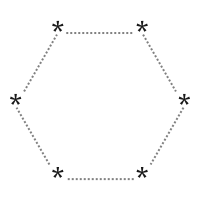
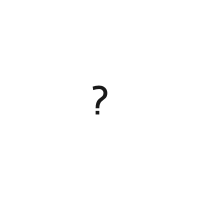
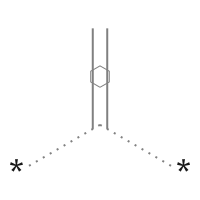
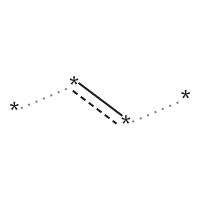
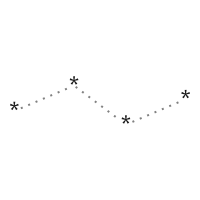
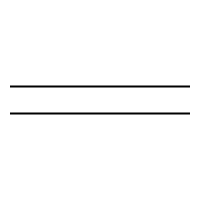
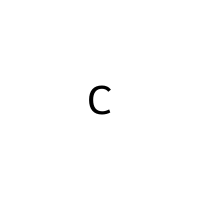
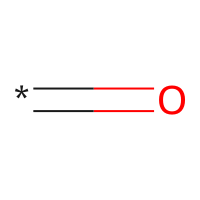
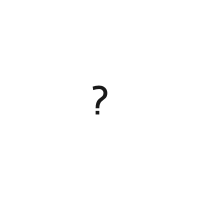

In [14]:
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import PandasTools

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (200,200)

PandasTools.RenderImagesInAllDataFrames(images=True)

feature_importance_df = add_maccs_metadata(feature_importance_df)
feature_importance_df.head(10)

## 8.3 Interpreting Feature Importance

The table above lists the most influential MACCS fingerprint features identified by the Random Forest model. Each row corresponds to one fingerprint bit and includes several pieces of information:

* feature – the original fingerprint column in the dataset (e.g., `maccs145`)
* importance – the relative contribution of that feature to the model. The values are normalized so that the importance scores for all features sum to 1. Larger values indicate that the feature played a greater role in reducing impurity across the trees in the Random Forest.
* bit – the MACCS key number
* SMARTS – the substructure pattern used to detect the feature
* feature_type – whether the key represents a substructure motif or a topological property
* mol – a visualization of the corresponding substructure when one exists

Higher importance values indicate that a feature played a larger role in separating active and inactive compounds during training. In many cases, these features correspond to recognizable chemical motifs, such as rings, double bonds, or functional groups.

However, feature importance values should be interpreted carefully:

* They indicate relative influence, not causal relationships.
* Correlated features may share importance.
* Some features may appear important simply because they occur frequently in the dataset.
* Not all fingerprint bits correspond to specific substructures. Some MACCS keys represent topological or algorithmic properties, which cannot be visualized as SMARTS patterns.

Despite these limitations, feature importance can provide useful insights into which **structural patterns or molecular properties** are most strongly associated with activity in the dataset.

# 9. Comparing Machine Learning Models

## 9.1 Run All 3 Models in one code cell

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

variance_filter = VarianceThreshold()

models = {
    "Naive Bayes": Pipeline([
        ("var", variance_filter),
        ("clf", BernoulliNB())
    ]),

    "Decision Tree": Pipeline([
        ("var", variance_filter),
        ("clf", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("var", variance_filter),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ])
}

## 9.2 Train All Models in a Loop

In [16]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "probabilities": y_prob
    }

# 9.3 Compare All Models

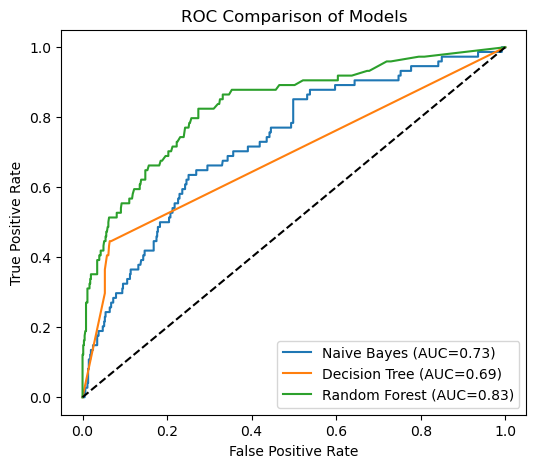

,accuracy,balanced_accuracy,auc
Naive Bayes,0.755882,0.661359,0.728682
Decision Tree,0.883824,0.656030,0.688041
Random Forest,0.911765,0.647980,0.832832


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve
)

import pandas as pd
import matplotlib.pyplot as plt


# -------------------------------------------------
# Define preprocessing
# -------------------------------------------------

variance_filter = VarianceThreshold()


# -------------------------------------------------
# Define model pipelines
# -------------------------------------------------

models = {
    "Naive Bayes": Pipeline([
        ("var", variance_filter),
        ("clf", BernoulliNB())
    ]),

    "Decision Tree": Pipeline([
        ("var", variance_filter),
        ("clf", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("var", variance_filter),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ])
}


# -------------------------------------------------
# Train models and collect metrics
# -------------------------------------------------

results = {}

plt.figure(figsize=(6,5))

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "auc": auc
    }

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")


# -------------------------------------------------
# Plot ROC comparison
# -------------------------------------------------

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison of Models")

plt.legend()
plt.show()


# -------------------------------------------------
# Display comparison table
# -------------------------------------------------

comparison_df = pd.DataFrame(results).T
comparison_df

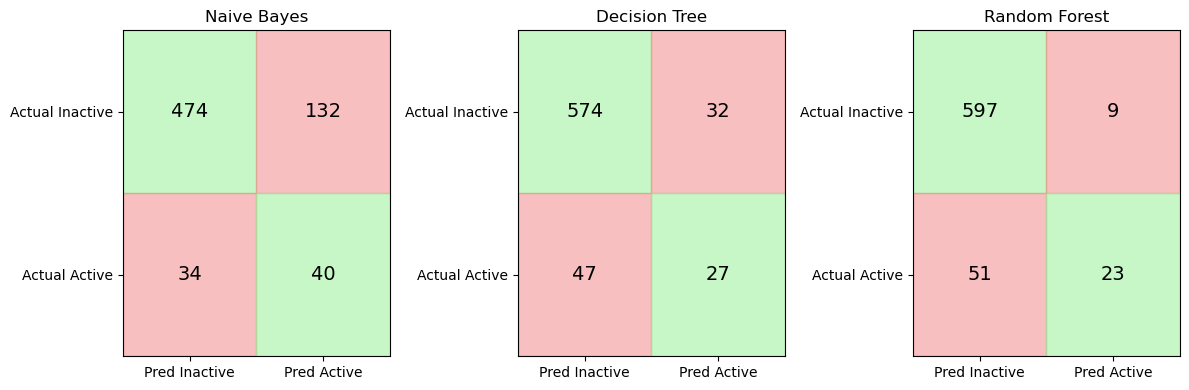

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, (name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    colors = np.array([
        ["lightgreen", "lightcoral"],
        ["lightcoral", "lightgreen"]
    ])

    for i in range(2):
        for j in range(2):

            ax.add_patch(
                plt.Rectangle((j, i), 1, 1,
                              color=colors[i, j],
                              alpha=0.5)
            )

            ax.text(
                j + 0.5,
                i + 0.5,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=14
            )

    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])

    ax.set_xticklabels(["Pred Inactive", "Pred Active"])
    ax.set_yticklabels(["Actual Inactive", "Actual Active"])

    ax.set_title(name)

    ax.set_xlim(0,2)
    ax.set_ylim(2,0)

plt.tight_layout()
plt.show()